# Análisis relacional de burnout estudiantil

Este notebook analiza las relaciones entre las variables del dataset **AI Dependency, Career Anxiety and Student Burnout** y la variable objetivo `burnout_score`.

La pregunta guía es:

**¿Qué variables subjetivas, conductuales y contextuales se relacionan con mayores niveles de burnout estudiantil, y cuáles de ellas podrían orientar una futura etapa de modelamiento predictivo?**

El análisis es exploratorio. Las asociaciones observadas no deben interpretarse como causalidad; su utilidad principal es identificar patrones, contrastar hipótesis y proponer variables candidatas para etapas posteriores de machine learning.

## 1. Hipótesis y enfoque por bloques

La hipótesis inicial es que los estudiantes con mayor dependencia de IA, mayor ansiedad profesional, mayor estrés y menor motivación tenderán a presentar mayores niveles de burnout.

Sin embargo, varias de esas variables son de **autopercepción** y su relación con burnout puede ser esperable. Por ello, el análisis se organiza en tres bloques:

1. **Variables subjetivas:** estrés, motivación, ansiedad, dependencia de IA y percepción de preparación profesional.
2. **Variables conductuales:** uso de IA, horas de sueño, estudio, redes sociales, postulaciones, cursos, prácticas y búsqueda de orientación.
3. **Variables contextuales:** edad, género, área de estudio, tipo de institución, año académico, zona y herramienta principal de IA.

Esta separación permite conservar las relaciones fuertes, pero también explorar patrones menos obvios que podrían aportar valor a la futura etapa de modelamiento.

## 2. Configuración y carga de datos

Se cargan las librerías principales y el dataset limpio generado en la etapa de preparación de datos.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

TARGET = "burnout_score"

# Ruta esperada dentro del proyecto y rutas de respaldo para ejecución local.
candidate_paths = [
    Path.cwd() / "data" / "processed" / "dataset_limpio.csv",
    Path.cwd().parent / "data" / "processed" / "dataset_limpio.csv",
    Path.cwd() / "dataset_limpio.csv",
    Path("/mnt/data/dataset_limpio.csv"),
]

DATA_PATH = next((path for path in candidate_paths if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("No se encontró dataset_limpio.csv en las rutas esperadas.")

PROJECT_ROOT = DATA_PATH.parents[2] if DATA_PATH.match("*/data/processed/dataset_limpio.csv") else DATA_PATH.parent
OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tablas"
OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

if TARGET not in df.columns:
    raise ValueError(f"La variable objetivo {TARGET!r} no existe en el dataset.")

display(Markdown(f"Dataset cargado desde `{DATA_PATH}`."))
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")
df.head()

Dataset cargado desde `/home/chop/Ufro/proyecto-ingenieria-datos/data/processed/dataset_limpio.csv`.

Filas: 11,119
Columnas: 30


,student_id,age,gender,degree_type,stream,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,primary_ai_tools_used,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
0,STU_00001,25,Male,B.Tech/B.E.,Engineering (Non-CS),3,Tier 3,Rural,0.3,Perplexity,...,3.5,8.7,2,1.5,8.5,1,3,6,0.0,9.09
1,STU_00002,20,Female,B.Tech/B.E.,Engineering (Non-CS),4,Tier 3,Urban,1.9,ChatGPT,...,2.4,8.2,3,4.2,8.3,4,5,3,0.0,6.03
2,STU_00003,25,Female,MBA,CS/IT,1,Tier 3,Urban,3.6,Gemini,...,2.3,16.4,1,2.3,7.0,5,9,3,1.0,6.68
3,STU_00004,23,Male,B.Tech/B.E.,CS/IT,1,Tier 1,Urban,4.1,GitHub Copilot,...,7.7,15.0,3,2.6,7.2,6,6,6,0.0,7.71
4,STU_00005,22,Female,MBA,CS/IT,1,Tier 1,Urban,3.4,ChatGPT,...,2.4,1.1,2,1.9,8.0,3,5,4,0.0,4.64


In [2]:
validation_summary = pd.DataFrame({
    "variable": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "nulos": df.isna().sum().values,
    "porcentaje_nulos": (df.isna().mean().values * 100).round(2),
    "valores_unicos": df.nunique(dropna=False).values,
})

duplicados = df.duplicated().sum()

print(f"Duplicados exactos: {duplicados}")
display(validation_summary)

Duplicados exactos: 0


,variable,dtype,nulos,porcentaje_nulos,valores_unicos
0,student_id,str,0,0.0,11119
1,age,int64,0,0.0,11
2,gender,str,0,0.0,3
3,degree_type,str,0,0.0,4
4,stream,str,0,0.0,4
5,year_of_study,int64,0,0.0,4
6,college_tier,str,0,0.0,3
7,urban_or_rural,str,0,0.0,2
8,daily_ai_tool_usage_hrs,float64,0,0.0,79
9,primary_ai_tools_used,str,0,0.0,5


## 3. Selección de variables y bloques conceptuales

Se excluye `student_id` porque es un identificador. Las demás variables se agrupan según su función conceptual dentro del análisis.

In [3]:
subjective_vars = [
    "stress_level",
    "motivation_score",
    "placement_anxiety_score",
    "interview_anxiety_score",
    "fear_of_job_loss_to_ai",
    "ai_dependency_score",
    "ai_replaces_own_thinking_score",
    "career_clarity_score",
    "resume_confidence_score",
    "overall_career_readiness_score",
]

behavioral_vars = [
    "daily_ai_tool_usage_hrs",
    "daily_study_hours",
    "self_learning_hours_per_week",
    "skill_development_courses_taken",
    "social_media_hrs_per_day",
    "sleep_hours",
    "weekly_job_application_count",
    "internship_experience",
    "seeks_career_counseling",
]

contextual_numeric_vars = ["age"]

categorical_vars = [
    "gender",
    "degree_type",
    "stream",
    "year_of_study",
    "college_tier",
    "urban_or_rural",
    "primary_ai_tools_used",
    "uses_ai_for_assignments",
]

numeric_vars = subjective_vars + behavioral_vars + contextual_numeric_vars + [TARGET]

all_expected = numeric_vars + categorical_vars
missing = sorted(set(all_expected) - set(df.columns))
if missing:
    raise ValueError(f"Faltan variables esperadas: {missing}")

analysis_df = df.copy()
for col in numeric_vars:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

analysis_df["year_of_study"] = analysis_df["year_of_study"].astype(str)
analysis_df["seeks_career_counseling_label"] = analysis_df["seeks_career_counseling"].map({0.0: "No", 1.0: "Sí"})
analysis_df["internship_experience_label"] = analysis_df["internship_experience"].astype(int).astype(str)

variable_blocks = {}
variable_blocks.update({var: "Subjetiva / autopercepción" for var in subjective_vars})
variable_blocks.update({var: "Conductual / hábitos" for var in behavioral_vars})
variable_blocks.update({var: "Contextual / demográfica" for var in contextual_numeric_vars + categorical_vars})
variable_blocks[TARGET] = "Variable objetivo"

block_table = pd.DataFrame(
    [{"variable": var, "bloque": block} for var, block in variable_blocks.items() if var != TARGET]
).sort_values(["bloque", "variable"])

display(block_table)

,variable,bloque
10,daily_ai_tool_usage_hrs,Conductual / hábitos
11,daily_study_hours,Conductual / hábitos
17,internship_experience,Conductual / hábitos
18,seeks_career_counseling,Conductual / hábitos
12,self_learning_hours_per_week,Conductual / hábitos
13,skill_development_courses_taken,Conductual / hábitos
15,sleep_hours,Conductual / hábitos
14,social_media_hrs_per_day,Conductual / hábitos
16,weekly_job_application_count,Conductual / hábitos
19,age,Contextual / demográfica


## 4. Correlaciones numéricas con `burnout_score`

Se utiliza correlación de Spearman porque varias variables corresponden a puntajes o escalas ordinales. Además del ranking global, se identifica el bloque conceptual de cada variable para distinguir relaciones esperables de autopercepción frente a patrones conductuales o contextuales.

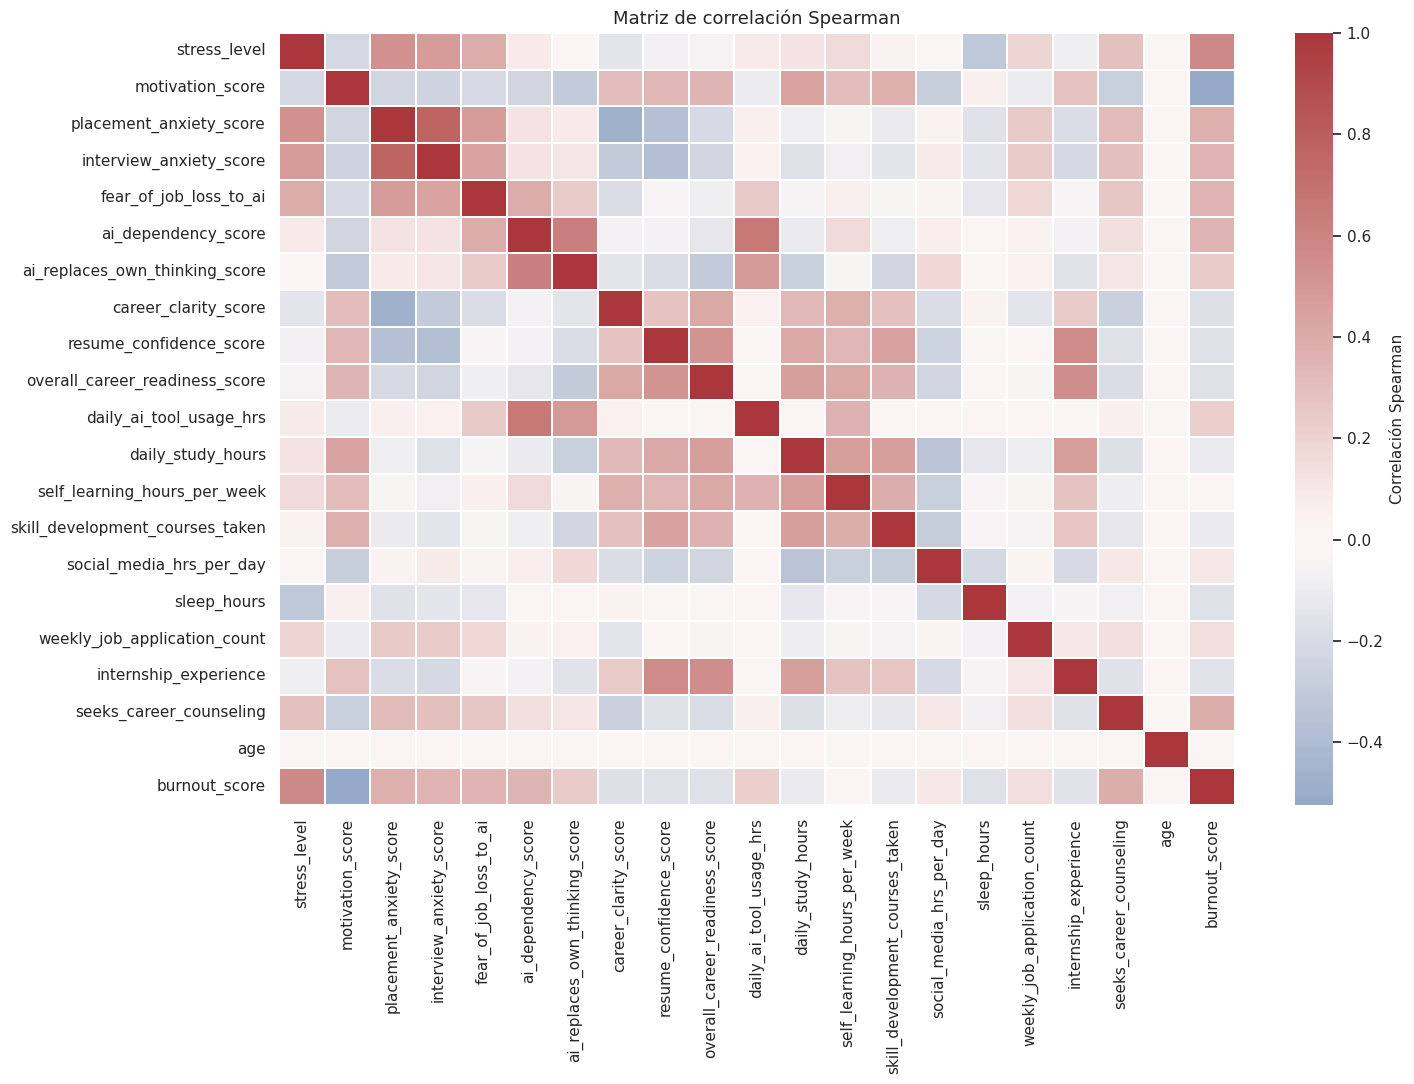

,variable,correlacion_spearman,abs_correlacion,bloque
0,stress_level,0.577417,0.577417,Subjetiva / autopercepción
1,motivation_score,-0.523542,0.523542,Subjetiva / autopercepción
2,seeks_career_counseling,0.386275,0.386275,Conductual / hábitos
3,placement_anxiety_score,0.370386,0.370386,Subjetiva / autopercepción
4,interview_anxiety_score,0.355644,0.355644,Subjetiva / autopercepción
5,fear_of_job_loss_to_ai,0.355073,0.355073,Subjetiva / autopercepción
6,ai_dependency_score,0.350719,0.350719,Subjetiva / autopercepción
7,ai_replaces_own_thinking_score,0.243362,0.243362,Subjetiva / autopercepción
8,daily_ai_tool_usage_hrs,0.224645,0.224645,Conductual / hábitos
9,career_clarity_score,-0.177901,0.177901,Subjetiva / autopercepción


In [4]:
corr_spearman = analysis_df[numeric_vars].corr(method="spearman")

plt.figure(figsize=(15, 11))
sns.heatmap(
    corr_spearman,
    cmap="vlag",
    center=0,
    linewidths=0.3,
    cbar_kws={"label": "Correlación Spearman"},
)
plt.title("Matriz de correlación Spearman")
plt.tight_layout()
plt.show()

ranking_correlaciones = (
    corr_spearman[TARGET]
    .drop(labels=[TARGET])
    .rename("correlacion_spearman")
    .reset_index()
    .rename(columns={"index": "variable"})
)
ranking_correlaciones["abs_correlacion"] = ranking_correlaciones["correlacion_spearman"].abs()
ranking_correlaciones["bloque"] = ranking_correlaciones["variable"].map(variable_blocks)
ranking_correlaciones = ranking_correlaciones.sort_values("abs_correlacion", ascending=False).reset_index(drop=True)

ranking_correlaciones.to_csv(OUTPUT_TABLES_DIR / "ranking_correlaciones_burnout.csv", index=False)

display(ranking_correlaciones)

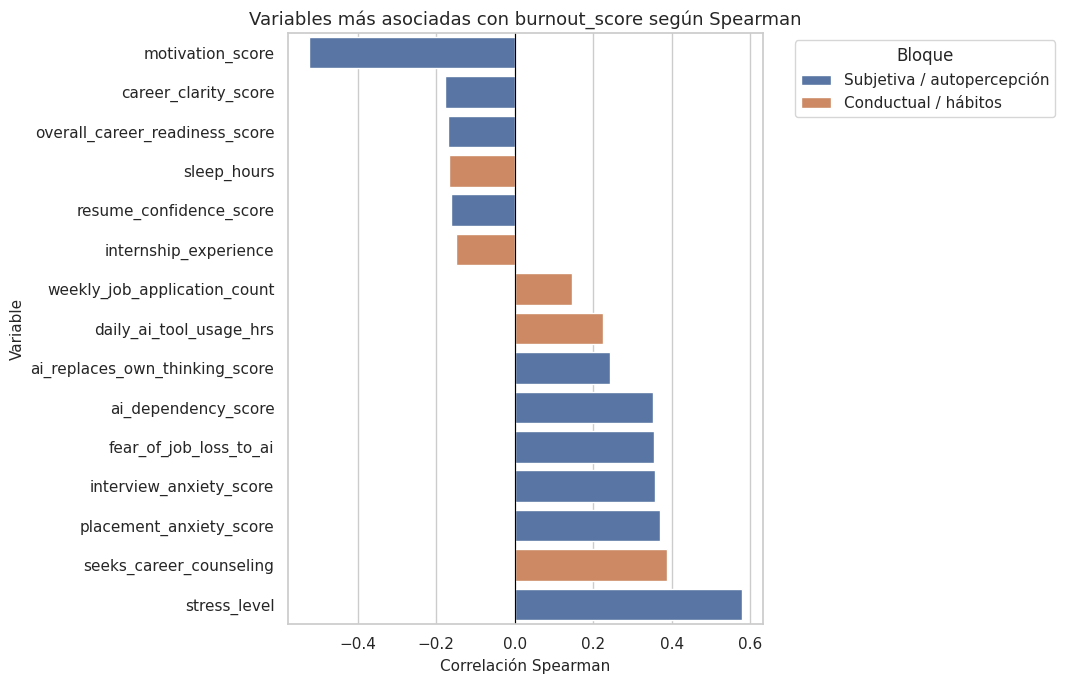

In [5]:
plt.figure(figsize=(11, 7))
bar_df = ranking_correlaciones.head(15).sort_values("correlacion_spearman")
sns.barplot(
    data=bar_df,
    x="correlacion_spearman",
    y="variable",
    hue="bloque",
    dodge=False,
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Variables más asociadas con burnout_score según Spearman")
plt.xlabel("Correlación Spearman")
plt.ylabel("Variable")
plt.legend(title="Bloque", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [6]:
block_summary = (
    ranking_correlaciones
    .groupby("bloque")
    .agg(
        variables=("variable", "count"),
        media_abs_correlacion=("abs_correlacion", "mean"),
        max_abs_correlacion=("abs_correlacion", "max"),
        variable_mas_relacionada=("variable", lambda s: ranking_correlaciones.loc[s.index[0], "variable"]),
    )
    .reset_index()
)
block_summary["media_abs_correlacion"] = block_summary["media_abs_correlacion"].round(3)
block_summary["max_abs_correlacion"] = block_summary["max_abs_correlacion"].round(3)

display(Markdown("**Resumen de correlaciones por bloque conceptual:**"))
display(block_summary)

for block in ranking_correlaciones["bloque"].dropna().unique():
    display(Markdown(f"**Top variables del bloque: {block}**"))
    display(ranking_correlaciones[ranking_correlaciones["bloque"] == block].head(6))

**Resumen de correlaciones por bloque conceptual:**

,bloque,variables,media_abs_correlacion,max_abs_correlacion,variable_mas_relacionada
0,Conductual / hábitos,9,0.157,0.386,seeks_career_counseling
1,Contextual / demográfica,1,0.006,0.006,age
2,Subjetiva / autopercepción,10,0.329,0.577,stress_level


**Top variables del bloque: Subjetiva / autopercepción**

,variable,correlacion_spearman,abs_correlacion,bloque
0,stress_level,0.577417,0.577417,Subjetiva / autopercepción
1,motivation_score,-0.523542,0.523542,Subjetiva / autopercepción
3,placement_anxiety_score,0.370386,0.370386,Subjetiva / autopercepción
4,interview_anxiety_score,0.355644,0.355644,Subjetiva / autopercepción
5,fear_of_job_loss_to_ai,0.355073,0.355073,Subjetiva / autopercepción
6,ai_dependency_score,0.350719,0.350719,Subjetiva / autopercepción


**Top variables del bloque: Conductual / hábitos**

,variable,correlacion_spearman,abs_correlacion,bloque
2,seeks_career_counseling,0.386275,0.386275,Conductual / hábitos
8,daily_ai_tool_usage_hrs,0.224645,0.224645,Conductual / hábitos
11,sleep_hours,-0.167434,0.167434,Conductual / hábitos
13,internship_experience,-0.151079,0.151079,Conductual / hábitos
14,weekly_job_application_count,0.144261,0.144261,Conductual / hábitos
15,daily_study_hours,-0.111862,0.111862,Conductual / hábitos


**Top variables del bloque: Contextual / demográfica**

,variable,correlacion_spearman,abs_correlacion,bloque
19,age,0.006209,0.006209,Contextual / demográfica


## 5. Relaciones bivariadas numéricas

Se grafican variables subjetivas y conductuales. Las subjetivas permiten revisar coherencia interna del dataset, mientras que las conductuales ayudan a detectar patrones menos directos.

La línea de tendencia se usa solo como apoyo visual. En variables discretas o de escala, no debe interpretarse como una relación exacta ni causal.

### Variables subjetivas o de autopercepción

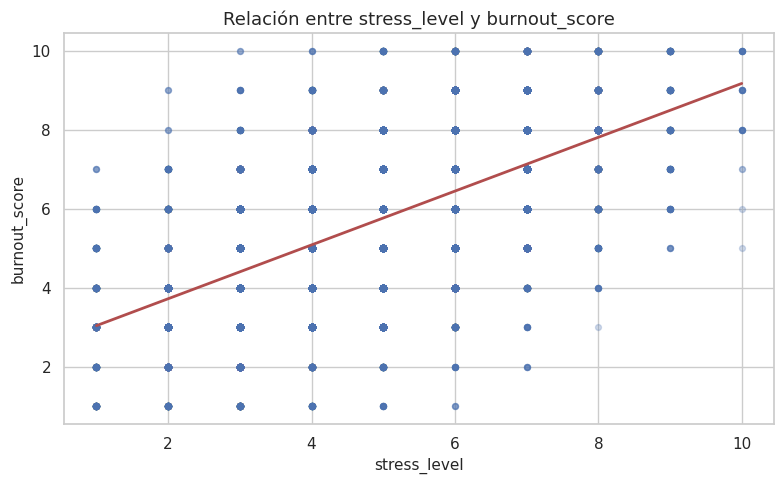

**Interpretación:** `stress_level` pertenece al bloque **Subjetiva / autopercepción** y muestra una relación positiva fuerte con `burnout_score` (Spearman = 0.577). En este dataset, valores más altos de `stress_level` tienden a observarse junto con mayor burnout. La lectura es exploratoria, no causal. Al ser una escala discreta o de autopercepción, debe interpretarse con cautela.

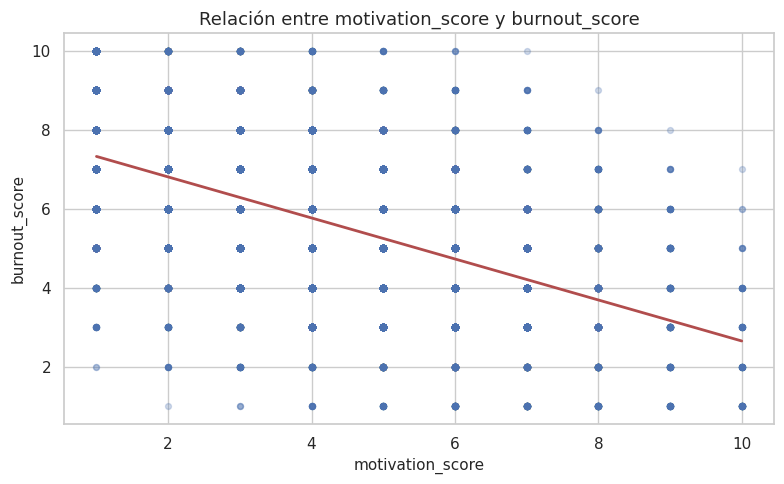

**Interpretación:** `motivation_score` pertenece al bloque **Subjetiva / autopercepción** y muestra una relación negativa fuerte con `burnout_score` (Spearman = -0.524). En este dataset, valores más altos de `motivation_score` tienden a observarse junto con menor burnout. La lectura es exploratoria, no causal. Al ser una escala discreta o de autopercepción, debe interpretarse con cautela.

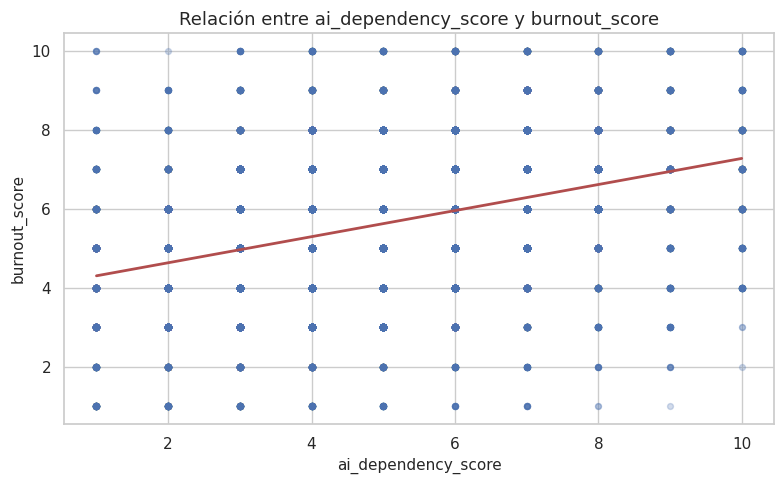

**Interpretación:** `ai_dependency_score` pertenece al bloque **Subjetiva / autopercepción** y muestra una relación positiva moderada con `burnout_score` (Spearman = 0.351). En este dataset, valores más altos de `ai_dependency_score` tienden a observarse junto con mayor burnout. La lectura es exploratoria, no causal. Al ser una escala discreta o de autopercepción, debe interpretarse con cautela.

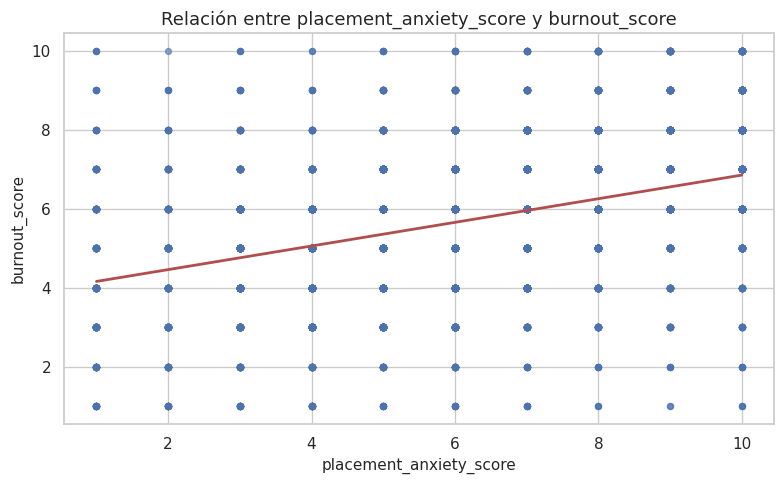

**Interpretación:** `placement_anxiety_score` pertenece al bloque **Subjetiva / autopercepción** y muestra una relación positiva moderada con `burnout_score` (Spearman = 0.370). En este dataset, valores más altos de `placement_anxiety_score` tienden a observarse junto con mayor burnout. La lectura es exploratoria, no causal. Al ser una escala discreta o de autopercepción, debe interpretarse con cautela.

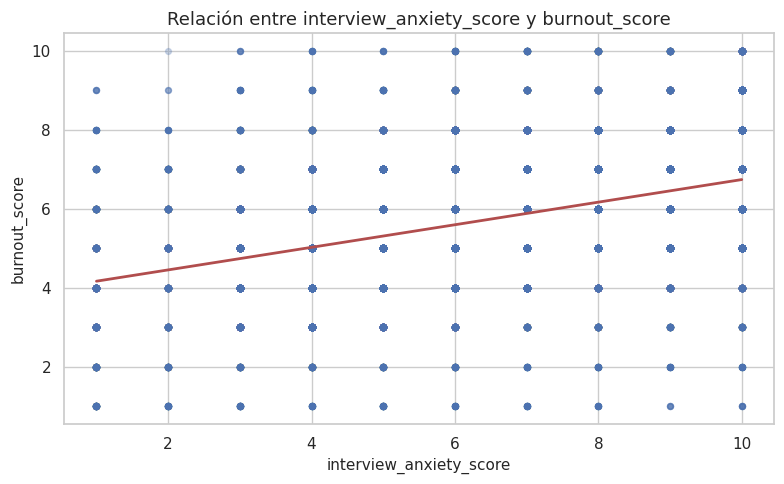

**Interpretación:** `interview_anxiety_score` pertenece al bloque **Subjetiva / autopercepción** y muestra una relación positiva moderada con `burnout_score` (Spearman = 0.356). En este dataset, valores más altos de `interview_anxiety_score` tienden a observarse junto con mayor burnout. La lectura es exploratoria, no causal. Al ser una escala discreta o de autopercepción, debe interpretarse con cautela.

### Variables conductuales o de hábitos

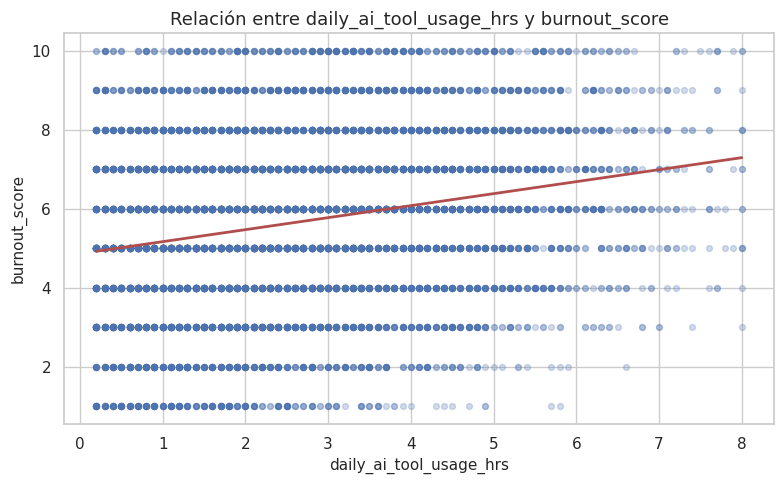

**Interpretación:** `daily_ai_tool_usage_hrs` pertenece al bloque **Conductual / hábitos** y muestra una relación positiva débil con `burnout_score` (Spearman = 0.225). En este dataset, valores más altos de `daily_ai_tool_usage_hrs` tienden a observarse junto con mayor burnout. La lectura es exploratoria, no causal.

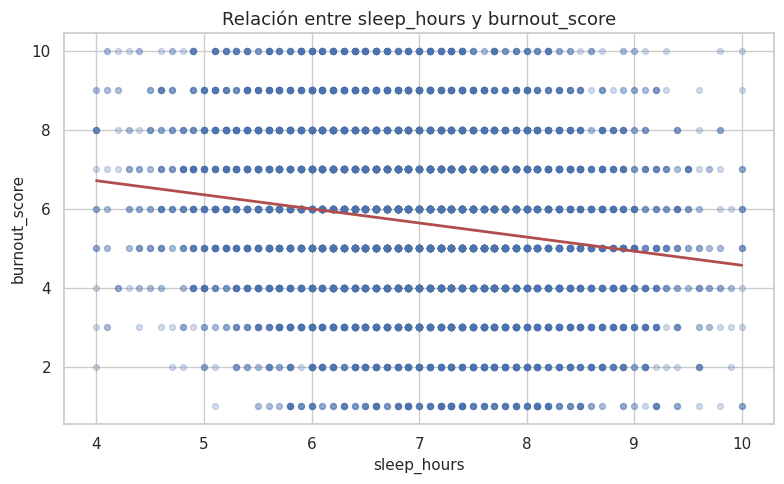

**Interpretación:** `sleep_hours` pertenece al bloque **Conductual / hábitos** y muestra una relación negativa débil con `burnout_score` (Spearman = -0.167). En este dataset, valores más altos de `sleep_hours` tienden a observarse junto con menor burnout. La lectura es exploratoria, no causal.

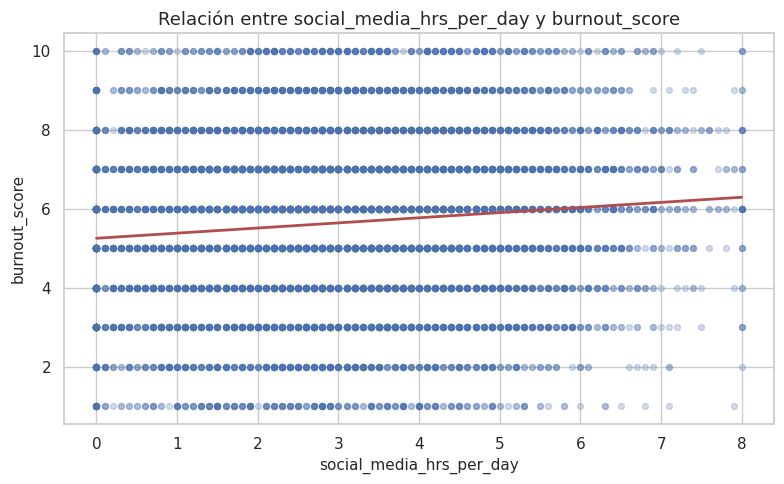

**Interpretación:** `social_media_hrs_per_day` pertenece al bloque **Conductual / hábitos** y muestra una relación positiva muy débil con `burnout_score` (Spearman = 0.098). En este dataset, valores más altos de `social_media_hrs_per_day` tienden a observarse junto con mayor burnout. La lectura es exploratoria, no causal.

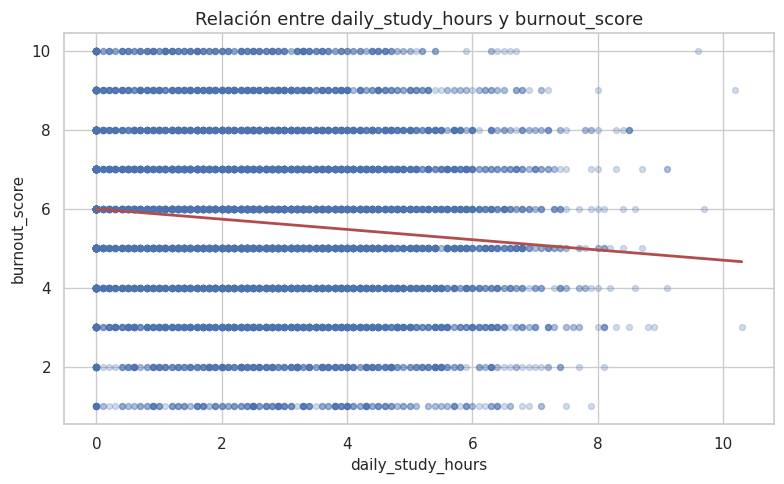

**Interpretación:** `daily_study_hours` pertenece al bloque **Conductual / hábitos** y muestra una relación negativa débil con `burnout_score` (Spearman = -0.112). En este dataset, valores más altos de `daily_study_hours` tienden a observarse junto con menor burnout. La lectura es exploratoria, no causal.

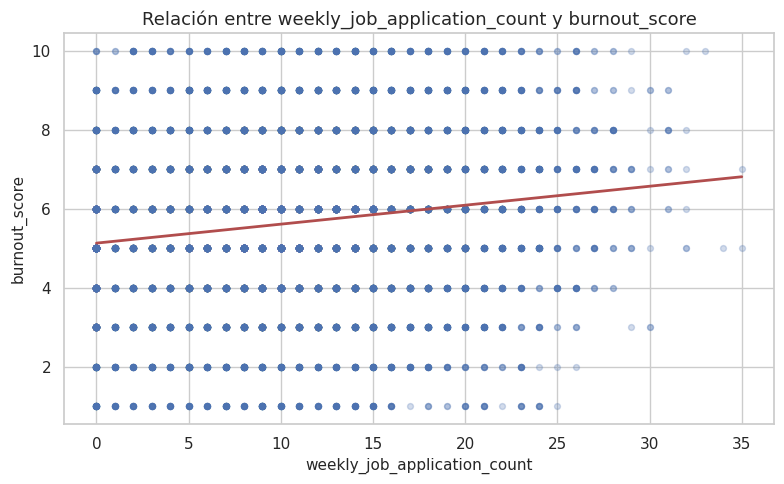

**Interpretación:** `weekly_job_application_count` pertenece al bloque **Conductual / hábitos** y muestra una relación positiva débil con `burnout_score` (Spearman = 0.144). En este dataset, valores más altos de `weekly_job_application_count` tienden a observarse junto con mayor burnout. La lectura es exploratoria, no causal.

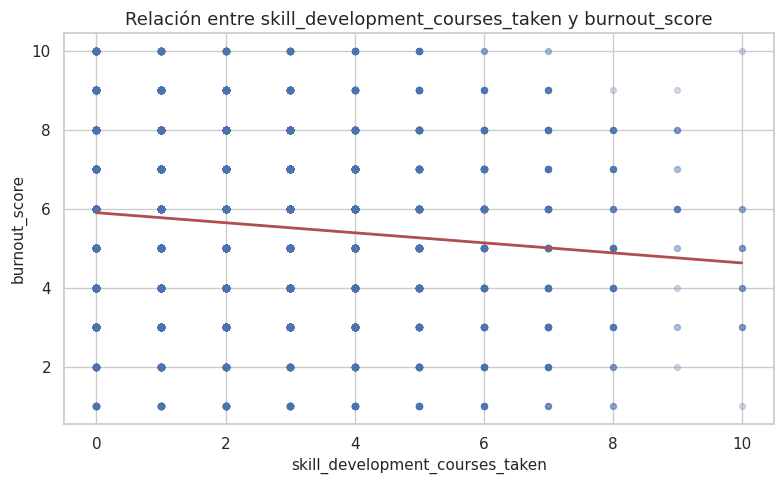

**Interpretación:** `skill_development_courses_taken` pertenece al bloque **Conductual / hábitos** y muestra una relación negativa débil con `burnout_score` (Spearman = -0.111). En este dataset, valores más altos de `skill_development_courses_taken` tienden a observarse junto con menor burnout. La lectura es exploratoria, no causal.

In [7]:
discrete_scale_vars = {
    "stress_level",
    "motivation_score",
    "ai_dependency_score",
    "placement_anxiety_score",
    "interview_anxiety_score",
    "fear_of_job_loss_to_ai",
    "ai_replaces_own_thinking_score",
    "career_clarity_score",
    "resume_confidence_score",
}

def relationship_strength(corr: float) -> str:
    if abs(corr) >= 0.50:
        return "fuerte"
    if abs(corr) >= 0.30:
        return "moderada"
    if abs(corr) >= 0.10:
        return "débil"
    return "muy débil"

def describe_numeric_relationship(var: str) -> str:
    row = ranking_correlaciones.loc[ranking_correlaciones["variable"] == var].iloc[0]
    corr = row["correlacion_spearman"]
    block = row["bloque"]
    direction = "positiva" if corr > 0 else "negativa"
    meaning = "mayor burnout" if corr > 0 else "menor burnout"
    caution = (
        " Al ser una escala discreta o de autopercepción, debe interpretarse con cautela."
        if var in discrete_scale_vars or block == "Subjetiva / autopercepción"
        else ""
    )
    return (
        f"**Interpretación:** `{var}` pertenece al bloque **{block}** y muestra una relación {direction} "
        f"{relationship_strength(corr)} con `{TARGET}` (Spearman = {corr:.3f}). En este dataset, valores más altos de `{var}` "
        f"tienden a observarse junto con {meaning}. La lectura es exploratoria, no causal.{caution}"
    )

def plot_numeric_relationships(vars_to_plot, section_title):
    display(Markdown(f"### {section_title}"))
    for var in vars_to_plot:
        plt.figure(figsize=(8, 5))
        sns.regplot(
            data=analysis_df,
            x=var,
            y=TARGET,
            scatter_kws={"alpha": 0.25, "s": 18},
            line_kws={"color": "#b14d4d", "linewidth": 2},
            ci=None,
        )
        plt.title(f"Relación entre {var} y {TARGET}")
        plt.xlabel(var)
        plt.ylabel(TARGET)
        plt.tight_layout()
        plt.show()
        display(Markdown(describe_numeric_relationship(var)))

subjective_scatter_vars = [
    "stress_level",
    "motivation_score",
    "ai_dependency_score",
    "placement_anxiety_score",
    "interview_anxiety_score",
]

behavioral_scatter_vars = [
    "daily_ai_tool_usage_hrs",
    "sleep_hours",
    "social_media_hrs_per_day",
    "daily_study_hours",
    "weekly_job_application_count",
    "skill_development_courses_taken",
]

plot_numeric_relationships(subjective_scatter_vars, "Variables subjetivas o de autopercepción")
plot_numeric_relationships(behavioral_scatter_vars, "Variables conductuales o de hábitos")

## 6. Comparaciones de burnout entre grupos

Antes de interpretar cada boxplot se revisan tablas con `count`, `mean`, `median`, `std`, `min` y `max`. El tamaño de grupo es parte de la interpretación: una media calculada con pocos registros puede ser menos representativa.

In [8]:
AI_USAGE_ORDER = ["Never", "Rarely", "Sometimes", "Frequently", "Always"]
MIN_GROUP_SIZE_FOR_INTERPRETATION = 30

analysis_df["uses_ai_for_assignments"] = pd.Categorical(
    analysis_df["uses_ai_for_assignments"],
    categories=AI_USAGE_ORDER,
    ordered=True,
)

analysis_df["seeks_career_counseling_label"] = pd.Categorical(
    analysis_df["seeks_career_counseling_label"],
    categories=["No", "Sí"],
    ordered=True,
)

def group_summary(variable: str) -> pd.DataFrame:
    summary = (
        analysis_df.groupby(variable, observed=True)[TARGET]
        .agg(count="count", mean="mean", median="median", std="std", min="min", max="max")
        .reset_index()
    )
    for col in ["mean", "median", "std"]:
        summary[col] = summary[col].round(2)
    return summary

main_group_vars = {
    "uses_ai_for_assignments": "Frecuencia de uso de IA en tareas",
    "primary_ai_tools_used": "Herramienta principal de IA",
    "stream": "Área de estudio",
    "college_tier": "Tipo de institución",
    "seeks_career_counseling_label": "Búsqueda de orientación profesional",
    "internship_experience_label": "Experiencia de práctica",
}

secondary_group_vars = {
    "gender": "Género",
    "degree_type": "Tipo de grado",
    "year_of_study": "Año de estudio",
    "urban_or_rural": "Zona urbana/rural",
}

summaries = {var: group_summary(var) for var in {**main_group_vars, **secondary_group_vars}}

export_names = {
    "uses_ai_for_assignments": "burnout_por_uso_ia.csv",
    "primary_ai_tools_used": "burnout_por_herramienta_ia.csv",
    "stream": "burnout_por_stream.csv",
    "college_tier": "burnout_por_college_tier.csv",
    "seeks_career_counseling_label": "burnout_por_orientacion_profesional.csv",
    "internship_experience_label": "burnout_por_experiencia_practica.csv",
    "gender": "burnout_por_genero.csv",
    "degree_type": "burnout_por_tipo_grado.csv",
    "year_of_study": "burnout_por_anio_estudio.csv",
    "urban_or_rural": "burnout_por_zona.csv",
}

for key, summary in summaries.items():
    summary.to_csv(OUTPUT_TABLES_DIR / export_names[key], index=False)

### Frecuencia de uso de IA en tareas

,uses_ai_for_assignments,count,mean,median,std,min,max
0,Never,1315,5.00,5.0,2.05,1,10
1,Rarely,3945,5.28,5.0,2.04,1,10
2,Sometimes,3400,5.82,6.0,2.00,1,10
3,Frequently,1780,6.19,6.0,1.95,1,10
4,Always,679,6.64,7.0,1.95,1,10


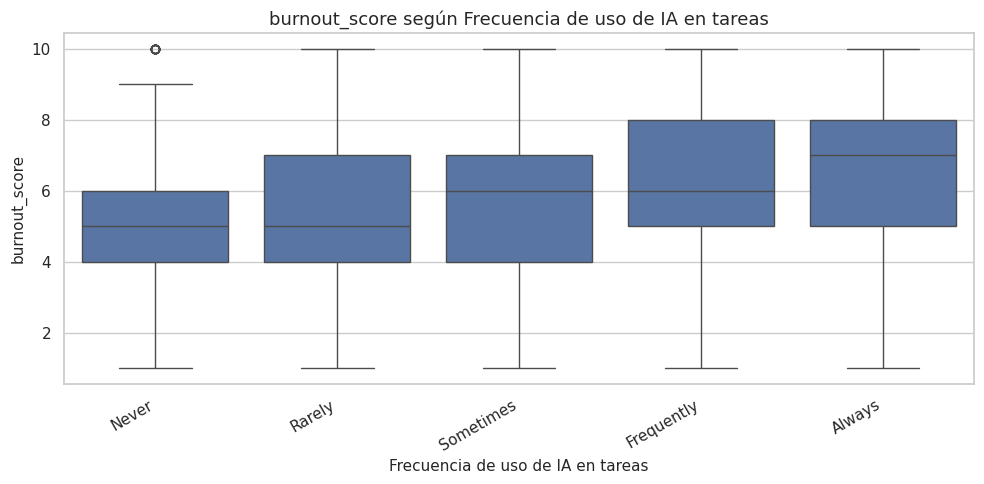

**Interpretación:** En `Frecuencia de uso de IA en tareas`, el mayor burnout medio aparece en `Always` (media = 6.64, n = 679), mientras que el menor aparece en `Never` (media = 5.00, n = 1315). La diferencia descriptiva entre medias es 1.64. Los tamaños de grupo son suficientes para una lectura descriptiva inicial.

### Herramienta principal de IA

,primary_ai_tools_used,count,mean,median,std,min,max
0,ChatGPT,5156,5.61,6.0,2.05,1,10
1,Claude,1779,5.63,6.0,2.07,1,10
2,Gemini,2331,5.47,5.0,2.05,1,10
3,GitHub Copilot,902,6.34,6.0,2.01,1,10
4,Perplexity,951,5.60,6.0,2.09,1,10


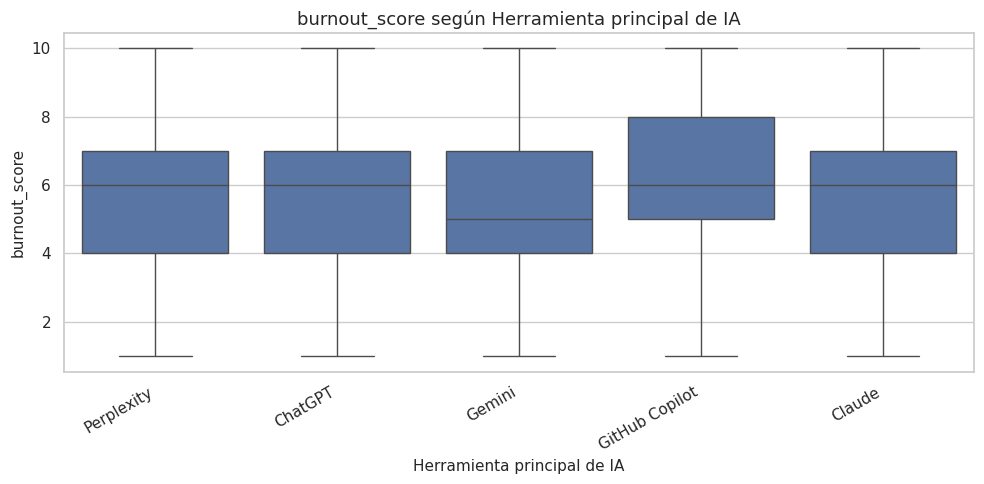

**Interpretación:** En `Herramienta principal de IA`, el mayor burnout medio aparece en `GitHub Copilot` (media = 6.34, n = 902), mientras que el menor aparece en `Gemini` (media = 5.47, n = 2331). La diferencia descriptiva entre medias es 0.87. Los tamaños de grupo son suficientes para una lectura descriptiva inicial.

### Área de estudio

,stream,count,mean,median,std,min,max
0,Arts/Sciences,1436,5.45,5.0,2.09,1,10
1,CS/IT,5445,5.87,6.0,2.04,1,10
2,Commerce/Management,1844,5.40,5.0,2.07,1,10
3,Engineering (Non-CS),2394,5.43,5.0,2.05,1,10


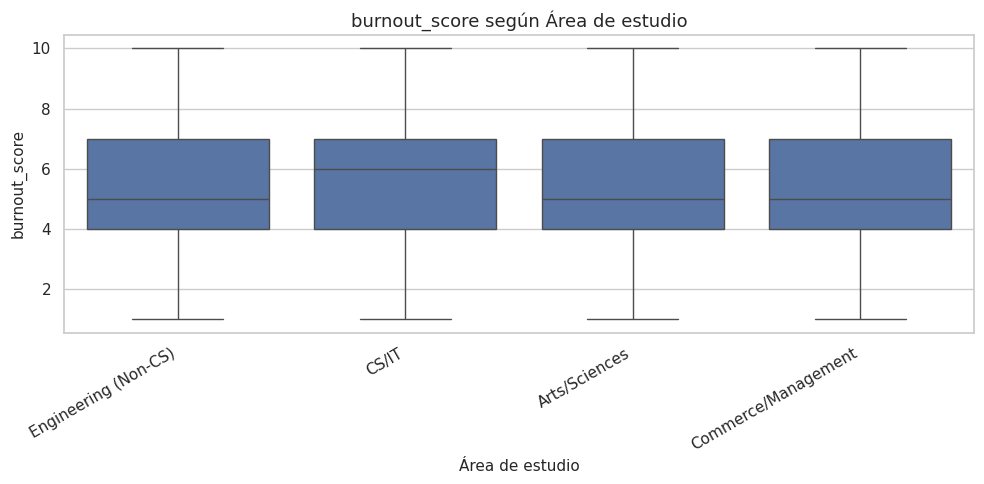

**Interpretación:** En `Área de estudio`, el mayor burnout medio aparece en `CS/IT` (media = 5.87, n = 5445), mientras que el menor aparece en `Commerce/Management` (media = 5.40, n = 1844). La diferencia descriptiva entre medias es 0.47. Los tamaños de grupo son suficientes para una lectura descriptiva inicial.

### Tipo de institución

,college_tier,count,mean,median,std,min,max
0,Tier 1,1656,5.30,5.0,2.05,1,10
1,Tier 2,3915,5.62,6.0,2.06,1,10
2,Tier 3,5548,5.76,6.0,2.06,1,10


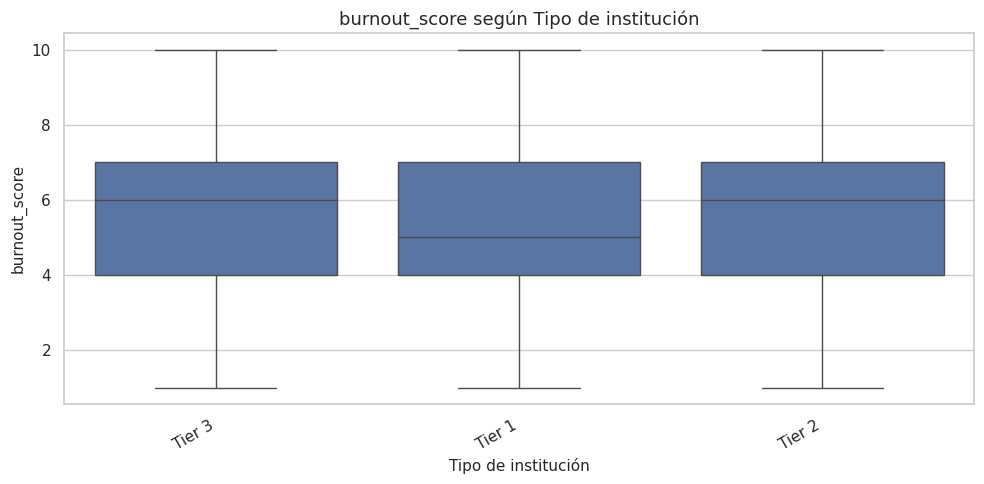

**Interpretación:** En `Tipo de institución`, el mayor burnout medio aparece en `Tier 3` (media = 5.76, n = 5548), mientras que el menor aparece en `Tier 1` (media = 5.30, n = 1656). La diferencia descriptiva entre medias es 0.46. Los tamaños de grupo son suficientes para una lectura descriptiva inicial.

### Búsqueda de orientación profesional

,seeks_career_counseling_label,count,mean,median,std,min,max
0,No,7881,5.13,5.0,1.93,1,10
1,Sí,3238,6.89,7.0,1.83,1,10


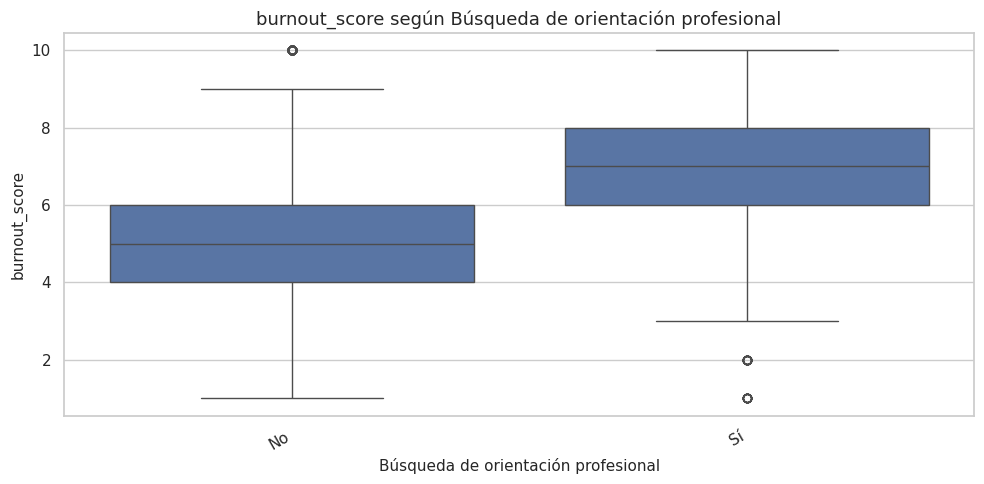

**Interpretación:** En `Búsqueda de orientación profesional`, el mayor burnout medio aparece en `Sí` (media = 6.89, n = 3238), mientras que el menor aparece en `No` (media = 5.13, n = 7881). La diferencia descriptiva entre medias es 1.76. Los tamaños de grupo son suficientes para una lectura descriptiva inicial.

### Experiencia de práctica

,internship_experience_label,count,mean,median,std,min,max
0,0,1472,6.17,6.0,1.98,1,10
1,1,3369,5.88,6.0,2.03,1,10
2,2,3699,5.50,6.0,2.07,1,10
3,3,1996,5.25,5.0,2.05,1,10
4,4,583,5.12,5.0,1.99,1,10


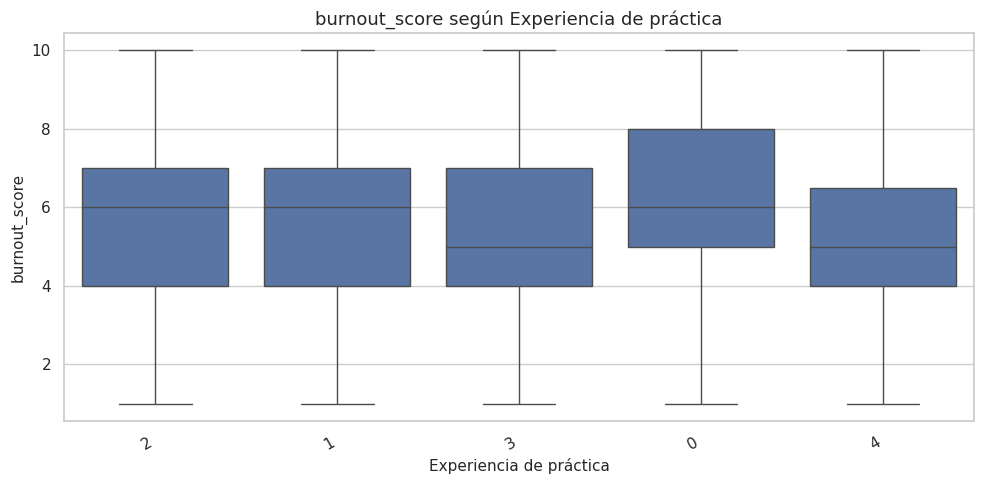

**Interpretación:** En `Experiencia de práctica`, el mayor burnout medio aparece en `0` (media = 6.17, n = 1472), mientras que el menor aparece en `4` (media = 5.12, n = 583). La diferencia descriptiva entre medias es 1.05. Los tamaños de grupo son suficientes para una lectura descriptiva inicial.

### Variables contextuales secundarias

Estas variables se revisan como contexto descriptivo. No se priorizan en los gráficos principales cuando las diferencias promedio son pequeñas o menos centrales para la hipótesis.

**Género**

,gender,count,mean,median,std,min,max
0,Female,4993,5.65,6.0,2.06,1,10
1,Male,5815,5.64,6.0,2.07,1,10
2,Non-binary,311,5.56,5.0,2.03,1,10


...

,degree_type,count,mean,median,std,min,max
0,B.Sc/B.A/B.Com,3357,5.66,6.0,2.06,1,10
1,B.Tech/B.E.,4990,5.61,6.0,2.09,1,10
2,M.Tech/M.Sc,1703,5.71,6.0,2.00,1,10
3,MBA,1069,5.63,6.0,2.06,1,10


**Año de estudio**

,year_of_study,count,mean,median,std,min,max
0,1,3715,5.76,6.0,2.06,1,10
1,2,3748,5.61,6.0,2.05,1,10
2,3,2416,5.58,6.0,2.06,1,10
3,4,1240,5.50,6.0,2.12,1,10


**Zona urbana/rural**

,urban_or_rural,count,mean,median,std,min,max
0,Rural,3527,5.67,6.0,2.05,1,10
1,Urban,7592,5.63,6.0,2.07,1,10


In [9]:
def interpret_group_summary(variable: str, label: str) -> str:
    summary = summaries[variable].copy()
    group_col = summary.columns[0]
    highest = summary.loc[summary["mean"].idxmax()]
    lowest = summary.loc[summary["mean"].idxmin()]
    spread = highest["mean"] - lowest["mean"]
    small_groups = summary.loc[summary["count"] < MIN_GROUP_SIZE_FOR_INTERPRETATION, group_col].tolist()
    caution = (
        f" Existen categorías con menos de {MIN_GROUP_SIZE_FOR_INTERPRETATION} registros ({small_groups}), por lo que deben interpretarse con cautela."
        if small_groups
        else " Los tamaños de grupo son suficientes para una lectura descriptiva inicial."
    )
    return (
        f"**Interpretación:** En `{label}`, el mayor burnout medio aparece en `{highest[group_col]}` "
        f"(media = {highest['mean']:.2f}, n = {int(highest['count'])}), mientras que el menor aparece en "
        f"`{lowest[group_col]}` (media = {lowest['mean']:.2f}, n = {int(lowest['count'])}). "
        f"La diferencia descriptiva entre medias es {spread:.2f}.{caution}"
    )

for var, label in main_group_vars.items():
    display(Markdown(f"### {label}"))
    display(summaries[var])
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=analysis_df, x=var, y=TARGET)
    plt.title(f"{TARGET} según {label}")
    plt.xlabel(label)
    plt.ylabel(TARGET)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
    display(Markdown(interpret_group_summary(var, label)))

display(Markdown("### Variables contextuales secundarias"))
display(Markdown(
    "Estas variables se revisan como contexto descriptivo. No se priorizan en los gráficos principales cuando las diferencias promedio son pequeñas o menos centrales para la hipótesis."
))
for var, label in secondary_group_vars.items():
    display(Markdown(f"**{label}**"))
    display(summaries[var])

## 7. Tabla final de variables candidatas para modelamiento

La tabla distingue el bloque conceptual de cada variable. Esto evita seleccionar variables solo por mayor correlación y permite considerar también variables menos directas pero relevantes para describir hábitos o contexto.

En variables numéricas, la métrica corresponde a Spearman. En variables categóricas, corresponde a la diferencia entre la media más alta y la media más baja de burnout entre grupos.

In [10]:
conceptual_priority = {
    # Subjetivas
    "stress_level": "Variable subjetiva fuertemente relacionada; útil como referencia, pero cercana conceptualmente al burnout.",
    "motivation_score": "Variable subjetiva con relación negativa; puede representar un factor asociado a menor burnout.",
    "placement_anxiety_score": "Ansiedad profesional; relevante para la hipótesis principal.",
    "interview_anxiety_score": "Ansiedad ante entrevistas; relevante para el componente de inserción laboral.",
    "fear_of_job_loss_to_ai": "Miedo a perder empleo por IA; conecta ansiedad laboral y tecnología.",
    "ai_dependency_score": "Dependencia de IA; eje central del dataset y de la problemática.",
    # Conductuales
    "daily_ai_tool_usage_hrs": "Hábito de uso de IA; variable menos directa que puede aportar al modelamiento.",
    "sleep_hours": "Hábito de bienestar; posible relación protectora.",
    "social_media_hrs_per_day": "Hábito digital; relación débil pero útil para contexto conductual.",
    "daily_study_hours": "Hábito académico; relación débil pero relevante para interpretar carga y organización.",
    "skill_development_courses_taken": "Conducta de formación; puede relacionarse con preparación y menor burnout.",
    "weekly_job_application_count": "Conducta asociada a búsqueda laboral; puede capturar presión de inserción.",
    "internship_experience": "Experiencia práctica; variable conductual/contextual con posible relación protectora.",
    "seeks_career_counseling": "Variable binaria de búsqueda de orientación; relación relevante, pero puede ser consecuencia del malestar.",
    # Contextual numérica
    "age": "Variable contextual de control; relación observada baja, pero puede mantenerse como descriptor.",
}

candidate_rows = []
for var, justification in conceptual_priority.items():
    row = ranking_correlaciones.loc[ranking_correlaciones["variable"] == var].iloc[0]
    corr = float(row["correlacion_spearman"])
    tipo = "binaria codificada" if var in ["seeks_career_counseling"] else "numérica"
    candidate_rows.append({
        "variable": var,
        "bloque": row["bloque"],
        "tipo_dato": tipo,
        "metrica_observada": "Spearman",
        "valor_observado": round(corr, 3),
        "direccion_observada": "positiva" if corr > 0 else "negativa",
        "justificacion": justification,
    })

categorical_candidates = [
    ("uses_ai_for_assignments", "Conductual / hábitos", "Frecuencia de uso de IA en tareas académicas."),
    ("primary_ai_tools_used", "Contextual / demográfica", "Herramienta principal de IA utilizada."),
    ("stream", "Contextual / demográfica", "Área de estudio."),
    ("college_tier", "Contextual / demográfica", "Tipo de institución."),
    ("gender", "Contextual / demográfica", "Género; diferencia descriptiva baja, útil como variable de control."),
    ("degree_type", "Contextual / demográfica", "Tipo de grado; diferencia descriptiva baja, útil como variable de control."),
    ("year_of_study", "Contextual / demográfica", "Año de estudio; útil para interpretar etapa académica."),
    ("urban_or_rural", "Contextual / demográfica", "Zona; diferencia descriptiva baja, útil como variable de control."),
]

for var, block, label in categorical_candidates:
    summary = summaries[var]
    spread = float(summary["mean"].max() - summary["mean"].min())
    candidate_rows.append({
        "variable": var,
        "bloque": block,
        "tipo_dato": "categórica",
        "metrica_observada": "Diferencia entre medias de grupos",
        "valor_observado": round(spread, 3),
        "direccion_observada": "diferencia entre grupos",
        "justificacion": f"{label} Diferencia descriptiva entre medias de burnout = {spread:.2f}; revisar junto con count por categoría.",
    })

variables_candidatas_modelamiento = pd.DataFrame(candidate_rows)
variables_candidatas_modelamiento.to_csv(
    OUTPUT_TABLES_DIR / "variables_candidatas_modelamiento.csv",
    index=False,
)
display(variables_candidatas_modelamiento)

,variable,bloque,tipo_dato,metrica_observada,valor_observado,direccion_observada,justificacion
0,stress_level,Subjetiva / autopercepción,numérica,Spearman,0.577,positiva,Variable subjetiva fuertemente relacionada; út...
1,motivation_score,Subjetiva / autopercepción,numérica,Spearman,-0.524,negativa,Variable subjetiva con relación negativa; pued...
2,placement_anxiety_score,Subjetiva / autopercepción,numérica,Spearman,0.370,positiva,Ansiedad profesional; relevante para la hipóte...
3,interview_anxiety_score,Subjetiva / autopercepción,numérica,Spearman,0.356,positiva,Ansiedad ante entrevistas; relevante para el c...
4,fear_of_job_loss_to_ai,Subjetiva / autopercepción,numérica,Spearman,0.355,positiva,Miedo a perder empleo por IA; conecta ansiedad...
5,ai_dependency_score,Subjetiva / autopercepción,numérica,Spearman,0.351,positiva,Dependencia de IA; eje central del dataset y d...
6,daily_ai_tool_usage_hrs,Conductual / hábitos,numérica,Spearman,0.225,positiva,Hábito de uso de IA; variable menos directa qu...
7,sleep_hours,Conductual / hábitos,numérica,Spearman,-0.167,negativa,Hábito de bienestar; posible relación protectora.
8,social_media_hrs_per_day,Conductual / hábitos,numérica,Spearman,0.098,positiva,Hábito digital; relación débil pero útil para ...
9,daily_study_hours,Conductual / hábitos,numérica,Spearman,-0.112,negativa,Hábito académico; relación débil pero relevant...


## 8. Conclusiones y hallazgos principales

Esta sección resume los patrones observados, distinguiendo entre relaciones esperables de autopercepción y patrones menos directos asociados a hábitos o contexto.

In [11]:
def get_corr(var: str) -> float:
    return float(ranking_correlaciones.loc[ranking_correlaciones["variable"] == var, "correlacion_spearman"].iloc[0])

def get_group_mean(variable: str, category) -> float:
    summary = summaries[variable]
    group_col = summary.columns[0]
    value = summary.loc[summary[group_col].astype(str) == str(category), "mean"]
    return float(value.iloc[0]) if not value.empty else np.nan

def final_conclusions() -> str:
    top = ranking_correlaciones.head(7)
    top_txt = ", ".join(
        f"`{row.variable}` ({row.correlacion_spearman:.3f})"
        for row in top.itertuples(index=False)
    )

    ai_never = get_group_mean("uses_ai_for_assignments", "Never")
    ai_always = get_group_mean("uses_ai_for_assignments", "Always")
    counseling_no = get_group_mean("seeks_career_counseling_label", "No")
    counseling_yes = get_group_mean("seeks_career_counseling_label", "Sí")
    copilot = get_group_mean("primary_ai_tools_used", "GitHub Copilot")
    csit = get_group_mean("stream", "CS/IT")
    tier3 = get_group_mean("college_tier", "Tier 3")

    return f"""
### Síntesis final

Las variables más relacionadas con `{TARGET}` según Spearman son: {top_txt}. Este resultado confirma que las variables de autopercepción, como estrés, motivación y ansiedad, concentran las asociaciones más fuertes. Esto es coherente con la hipótesis inicial, pero también era esperable por su cercanía conceptual con burnout.

Al separar las variables por bloques, el análisis gana una lectura más útil. Las variables subjetivas sirven para validar coherencia interna del dataset, mientras que las variables conductuales y contextuales permiten observar patrones menos directos. Entre estas últimas destacan `daily_ai_tool_usage_hrs` ({get_corr('daily_ai_tool_usage_hrs'):.3f}), `sleep_hours` ({get_corr('sleep_hours'):.3f}), `internship_experience` ({get_corr('internship_experience'):.3f}), `weekly_job_application_count` ({get_corr('weekly_job_application_count'):.3f}), `daily_study_hours` ({get_corr('daily_study_hours'):.3f}) y `skill_development_courses_taken` ({get_corr('skill_development_courses_taken'):.3f}). Aunque sus correlaciones son más bajas, aportan información relevante sobre hábitos y contexto del estudiante.

En las comparaciones por grupos también aparecen patrones descriptivos relevantes. El burnout medio aumenta desde {ai_never:.2f} en estudiantes que nunca usan IA para tareas hasta {ai_always:.2f} en quienes la usan siempre. Además, quienes buscan orientación profesional presentan mayor burnout medio ({counseling_yes:.2f}) que quienes no la buscan ({counseling_no:.2f}). También se observan medias más altas en usuarios de GitHub Copilot ({copilot:.2f}), estudiantes de CS/IT ({csit:.2f}) e instituciones Tier 3 ({tier3:.2f}).

Para una futura etapa de modelamiento, conviene evaluar dos enfoques: uno que incluya variables subjetivas, porque probablemente mejorarán la capacidad predictiva, y otro que priorice variables conductuales y contextuales, porque pueden entregar una lectura menos obvia y más explicativa desde el punto de vista del perfil del estudiante.

Limitaciones: este notebook realiza análisis bivariado exploratorio, no entrena modelos, no controla interacciones entre variables, no aplica pruebas inferenciales y no permite afirmar causalidad. Además, algunas variables subjetivas podrían estar muy cercanas conceptualmente al burnout, por lo que en la etapa de modelamiento se recomienda comparar modelos con y sin ese bloque de variables.
"""

display(Markdown(final_conclusions()))


### Síntesis final

Las variables más relacionadas con `burnout_score` según Spearman son: `stress_level` (0.577), `motivation_score` (-0.524), `seeks_career_counseling` (0.386), `placement_anxiety_score` (0.370), `interview_anxiety_score` (0.356), `fear_of_job_loss_to_ai` (0.355), `ai_dependency_score` (0.351). Este resultado confirma que las variables de autopercepción, como estrés, motivación y ansiedad, concentran las asociaciones más fuertes. Esto es coherente con la hipótesis inicial, pero también era esperable por su cercanía conceptual con burnout.

Al separar las variables por bloques, el análisis gana una lectura más útil. Las variables subjetivas sirven para validar coherencia interna del dataset, mientras que las variables conductuales y contextuales permiten observar patrones menos directos. Entre estas últimas destacan `daily_ai_tool_usage_hrs` (0.225), `sleep_hours` (-0.167), `internship_experience` (-0.151), `weekly_job_application_count` (0.144), `daily_study_hours` (-0.112) y `skill_development_courses_taken` (-0.111). Aunque sus correlaciones son más bajas, aportan información relevante sobre hábitos y contexto del estudiante.

En las comparaciones por grupos también aparecen patrones descriptivos relevantes. El burnout medio aumenta desde 5.00 en estudiantes que nunca usan IA para tareas hasta 6.64 en quienes la usan siempre. Además, quienes buscan orientación profesional presentan mayor burnout medio (6.89) que quienes no la buscan (5.13). También se observan medias más altas en usuarios de GitHub Copilot (6.34), estudiantes de CS/IT (5.87) e instituciones Tier 3 (5.76).

Para una futura etapa de modelamiento, conviene evaluar dos enfoques: uno que incluya variables subjetivas, porque probablemente mejorarán la capacidad predictiva, y otro que priorice variables conductuales y contextuales, porque pueden entregar una lectura menos obvia y más explicativa desde el punto de vista del perfil del estudiante.

Limitaciones: este notebook realiza análisis bivariado exploratorio, no entrena modelos, no controla interacciones entre variables, no aplica pruebas inferenciales y no permite afirmar causalidad. Además, algunas variables subjetivas podrían estar muy cercanas conceptualmente al burnout, por lo que en la etapa de modelamiento se recomienda comparar modelos con y sin ese bloque de variables.


### Conclusión fija para lectura sin ejecutar el notebook

El análisis muestra que las relaciones más fuertes con `burnout_score` aparecen en variables subjetivas o de autopercepción, especialmente estrés, motivación, ansiedad profesional, ansiedad en entrevistas, miedo laboral asociado a IA y dependencia de IA. Esto respalda la hipótesis inicial, pero también confirma que parte importante de la relación es esperable por la cercanía conceptual entre estas variables y el burnout.

Por esa razón, el análisis se complementa con variables conductuales y contextuales. En ese bloque aparecen patrones más débiles, pero útiles: frecuencia de uso de IA, horas de sueño, experiencia de práctica, postulaciones laborales, horas de estudio, cursos de desarrollo y uso de redes sociales. Estas variables pueden ser relevantes para una futura etapa de machine learning porque describen hábitos y condiciones del estudiante, no solo su autopercepción.

La recomendación para la siguiente fase es comparar al menos dos enfoques de modelamiento: uno con todas las variables relevantes y otro que priorice variables conductuales/contextuales. Así se podrá evaluar si el modelo depende demasiado de variables subjetivas o si también logra capturar patrones desde el perfil y comportamiento del estudiante.